In [6]:
import pandas as pd
import rapi    
import matplotlib.pyplot as plt
from PIL import Image
import requests
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import httpx
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap
import rapi

In [7]:
match_id = '839cf21b-1b7b-41a8-b1bb-b0817c031b13'
shard = 'eu'

In [8]:
kill_data, player_stats_df, economy_df, map_callouts, match_info, defuse_df = await rapi.main(match_id, shard)

In [9]:
kill_data

,round,killer,victim,gameTime,roundTime,victimLocation,playerLocations,assistants,finishingDamage,isSecondaryFireMode,killerAgent,victimAgent,killerAgentIcon,victimAgentIcon,killerLocation,displayName,displayIcon
0,0,inari#1314,Nailu#李诗琪,62206,7185,"(719.429632, 1090.521088)",[{'subject': '0e211d6a-a5c2-57ab-aa8d-f8fe164d...,[],"{'damageType': 'Weapon', 'damageItem': '1BAA85...",False,Gekko,Astra,https://media.valorant-api.com/agents/e370fa57...,https://media.valorant-api.com/agents/41fb69c1...,"(1403.2199679999999, 1062.98368)",Ghost,https://media.valorant-api.com/weapons/1baa85b...
1,0,BG Simply#nippa,Mtrx#vGood,62219,7198,"(935.913472, 1113.745408)",[{'subject': '0e211d6a-a5c2-57ab-aa8d-f8fe164d...,[],"{'damageType': 'Weapon', 'damageItem': '1BAA85...",False,Jett,Sova,https://media.valorant-api.com/agents/add6443a...,https://media.valorant-api.com/agents/320b2a48...,"(1248.612352, 882.16576)",Ghost,https://media.valorant-api.com/weapons/1baa85b...
2,0,PimpWomp#NASTY,castles#019,64402,9381,"(1343.3344, 340.70732799999996)",[{'subject': '0e211d6a-a5c2-57ab-aa8d-f8fe164d...,[cf7e43e4-3305-5925-8f9a-e8f7236992a4],"{'damageType': 'Weapon', 'damageItem': '29A0CF...",False,Astra,Jett,https://media.valorant-api.com/agents/41fb69c1...,https://media.valorant-api.com/agents/add6443a...,"(1325.91616, 512.23552)",Classic,https://media.valorant-api.com/weapons/29a0cfa...
3,0,lunar#ILMK,Imnotplaying#plyng,78313,23292,"(1154.885632, 205.176832)",[{'subject': '0e211d6a-a5c2-57ab-aa8d-f8fe164d...,[],"{'damageType': 'Weapon', 'damageItem': '29A0CF...",False,Vyse,Cypher,https://media.valorant-api.com/agents/efba5359...,https://media.valorant-api.com/agents/117ed9e3...,"(830.242816, 82.419712)",Classic,https://media.valorant-api.com/weapons/29a0cfa...
4,0,BG Simply#nippa,lunar#ILMK,81035,26014,"(819.12832, 124.55526399999997)",[{'subject': '0e211d6a-a5c2-57ab-aa8d-f8fe164d...,[0e211d6a-a5c2-57ab-aa8d-f8fe164dbda2],"{'damageType': 'Weapon', 'damageItem': '1BAA85...",False,Jett,Vyse,https://media.valorant-api.com/agents/add6443a...,https://media.valorant-api.com/agents/efba5359...,"(800.548864, 372.391936)",Ghost,https://media.valorant-api.com/weapons/1baa85b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,18,castles#019,PimpWomp#NASTY,1848749,4813,"(949.184512, 1916.809216)",[{'subject': 'c19bec43-cac7-5fee-b50e-46d20703...,[],"{'damageType': 'Ability', 'damageItem': 'Ultim...",False,Jett,Astra,https://media.valorant-api.com/agents/add6443a...,https://media.valorant-api.com/agents/41fb69c1...,"(1317.289984, 1684.731904)",Blade Storm,https://media.valorant-api.com/agents/add6443a...
132,18,froggienator#piss,BG Simply#nippa,1848764,4828,"(1115.072512, 1736.9866240000001)",[{'subject': '37742b18-2cc0-5567-88f4-6d63b7c1...,[],"{'damageType': 'Weapon', 'damageItem': '9C82E1...",False,Yoru,Jett,https://media.valorant-api.com/agents/7f94d92c...,https://media.valorant-api.com/agents/add6443a...,"(1410.8508160000001, 1847.302144)",Vandal,https://media.valorant-api.com/weapons/9c82e19...
133,18,castles#019,inari#1314,1859156,15220,"(742.985728, 1147.752448)",[{'subject': '37742b18-2cc0-5567-88f4-6d63b7c1...,[],"{'damageType': 'Ability', 'damageItem': 'Ultim...",False,Jett,Gekko,https://media.valorant-api.com/agents/add6443a...,https://media.valorant-api.com/agents/e370fa57...,"(696.702976, 1410.0213760000001)",Blade Storm,https://media.valorant-api.com/agents/add6443a...
134,18,castles#019,BG Nightzy#DBOZO,1862198,18262,"(738.340864, 1242.640384)",[{'subject': '37742b18-2cc0-5567-88f4-6d63b7c1...,[cc4b2628-1bc7-5744-9703-d403546871be],"{'damageType': 'Weapon', 'damageItem': 'EE8E8D...",False,Jett,Sova,https://media.valorant-api.com/agents/add6443a...,https://media.valorant-api.com/agents/320b2a48...,"(724.7380479999999, 1425.283072)",Phantom,https://media.valorant-api.com/weapons/ee8e8d1...


In [10]:
def get_agent_icon(url, zoom_factor=0.15):
    """ Download agent icon from URL and convert to a format suitable for matplotlib """
    response = requests.get(url, stream=True)
    img = Image.open(response.raw)
    img_array = np.array(img)
    return OffsetImage(img_array, zoom=zoom_factor)
 
index = 1  # Change this to visualize a different kill event
victim_location = kill_data['victimLocation'][index]
killer_location = kill_data['killerLocation'][index]
victim_agent_icon_url = kill_data['victimAgentIcon'][index]
killer_agent_icon_url = kill_data['killerAgentIcon'][index]
 
minimap_url = match_info['minimap'].values[0]
map_image = Image.open(requests.get(minimap_url, stream=True).raw)
 
map_name = match_info['map'].values[0] if 'map' in match_info.columns else minimap_url.split('/')[-1].split('.')[0].capitalize()
 
# Ensure that coordinates are numeric
victim_point = {'x': float(victim_location['x']), 'y': float(victim_location['y'])}
killer_point = {'x': float(killer_location['x']), 'y': float(killer_location['y'])}
 
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(map_image)
 
# Calculate arrow direction
dx = victim_point['x'] - killer_point['x']
dy = victim_point['y'] - killer_point['y']
 
# Plot arrow
ax.arrow(killer_point['x'] + dx * 0.1, killer_point['y'] + dy * 0.1,
         dx * 0.7, dy * 0.7, head_width=15, head_length=15, fc='red', ec='red',
         alpha=0.7, length_includes_head=True, width=2)
 
# Add agent icons
victim_icon = get_agent_icon(victim_agent_icon_url, zoom_factor=0.15)
killer_icon = get_agent_icon(killer_agent_icon_url, zoom_factor=0.15)
 
victim_box = AnnotationBbox(victim_icon, (victim_point['x'], victim_point['y']), frameon=False)
killer_box = AnnotationBbox(killer_icon, (killer_point['x'], killer_point['y']), frameon=False)
ax.add_artist(victim_box)
ax.add_artist(killer_box)
 
# Add a cross at the victim's position
cross_size = 30
ax.plot([victim_point['x'] - cross_size, victim_point['x'] + cross_size],
        [victim_point['y'] - cross_size, victim_point['y'] + cross_size],
        color='red', linewidth=3, zorder=10)
 
ax.plot([victim_point['x'] - cross_size, victim_point['x'] + cross_size],
        [victim_point['y'] + cross_size, victim_point['y'] - cross_size],
        color='red', linewidth=3, zorder=10)
 
# Add the title
round_num = kill_data['roundNum'][index] if 'roundNum' in kill_data.columns else 'Unknown'
ax.set_title(f'Kill Event on {map_name} (Round {round_num})')
 
# Remove axis ticks
ax.set_xticks([])
ax.set_yticks([])
 
plt.show()

TypeError: tuple indices must be integers or slices, not str

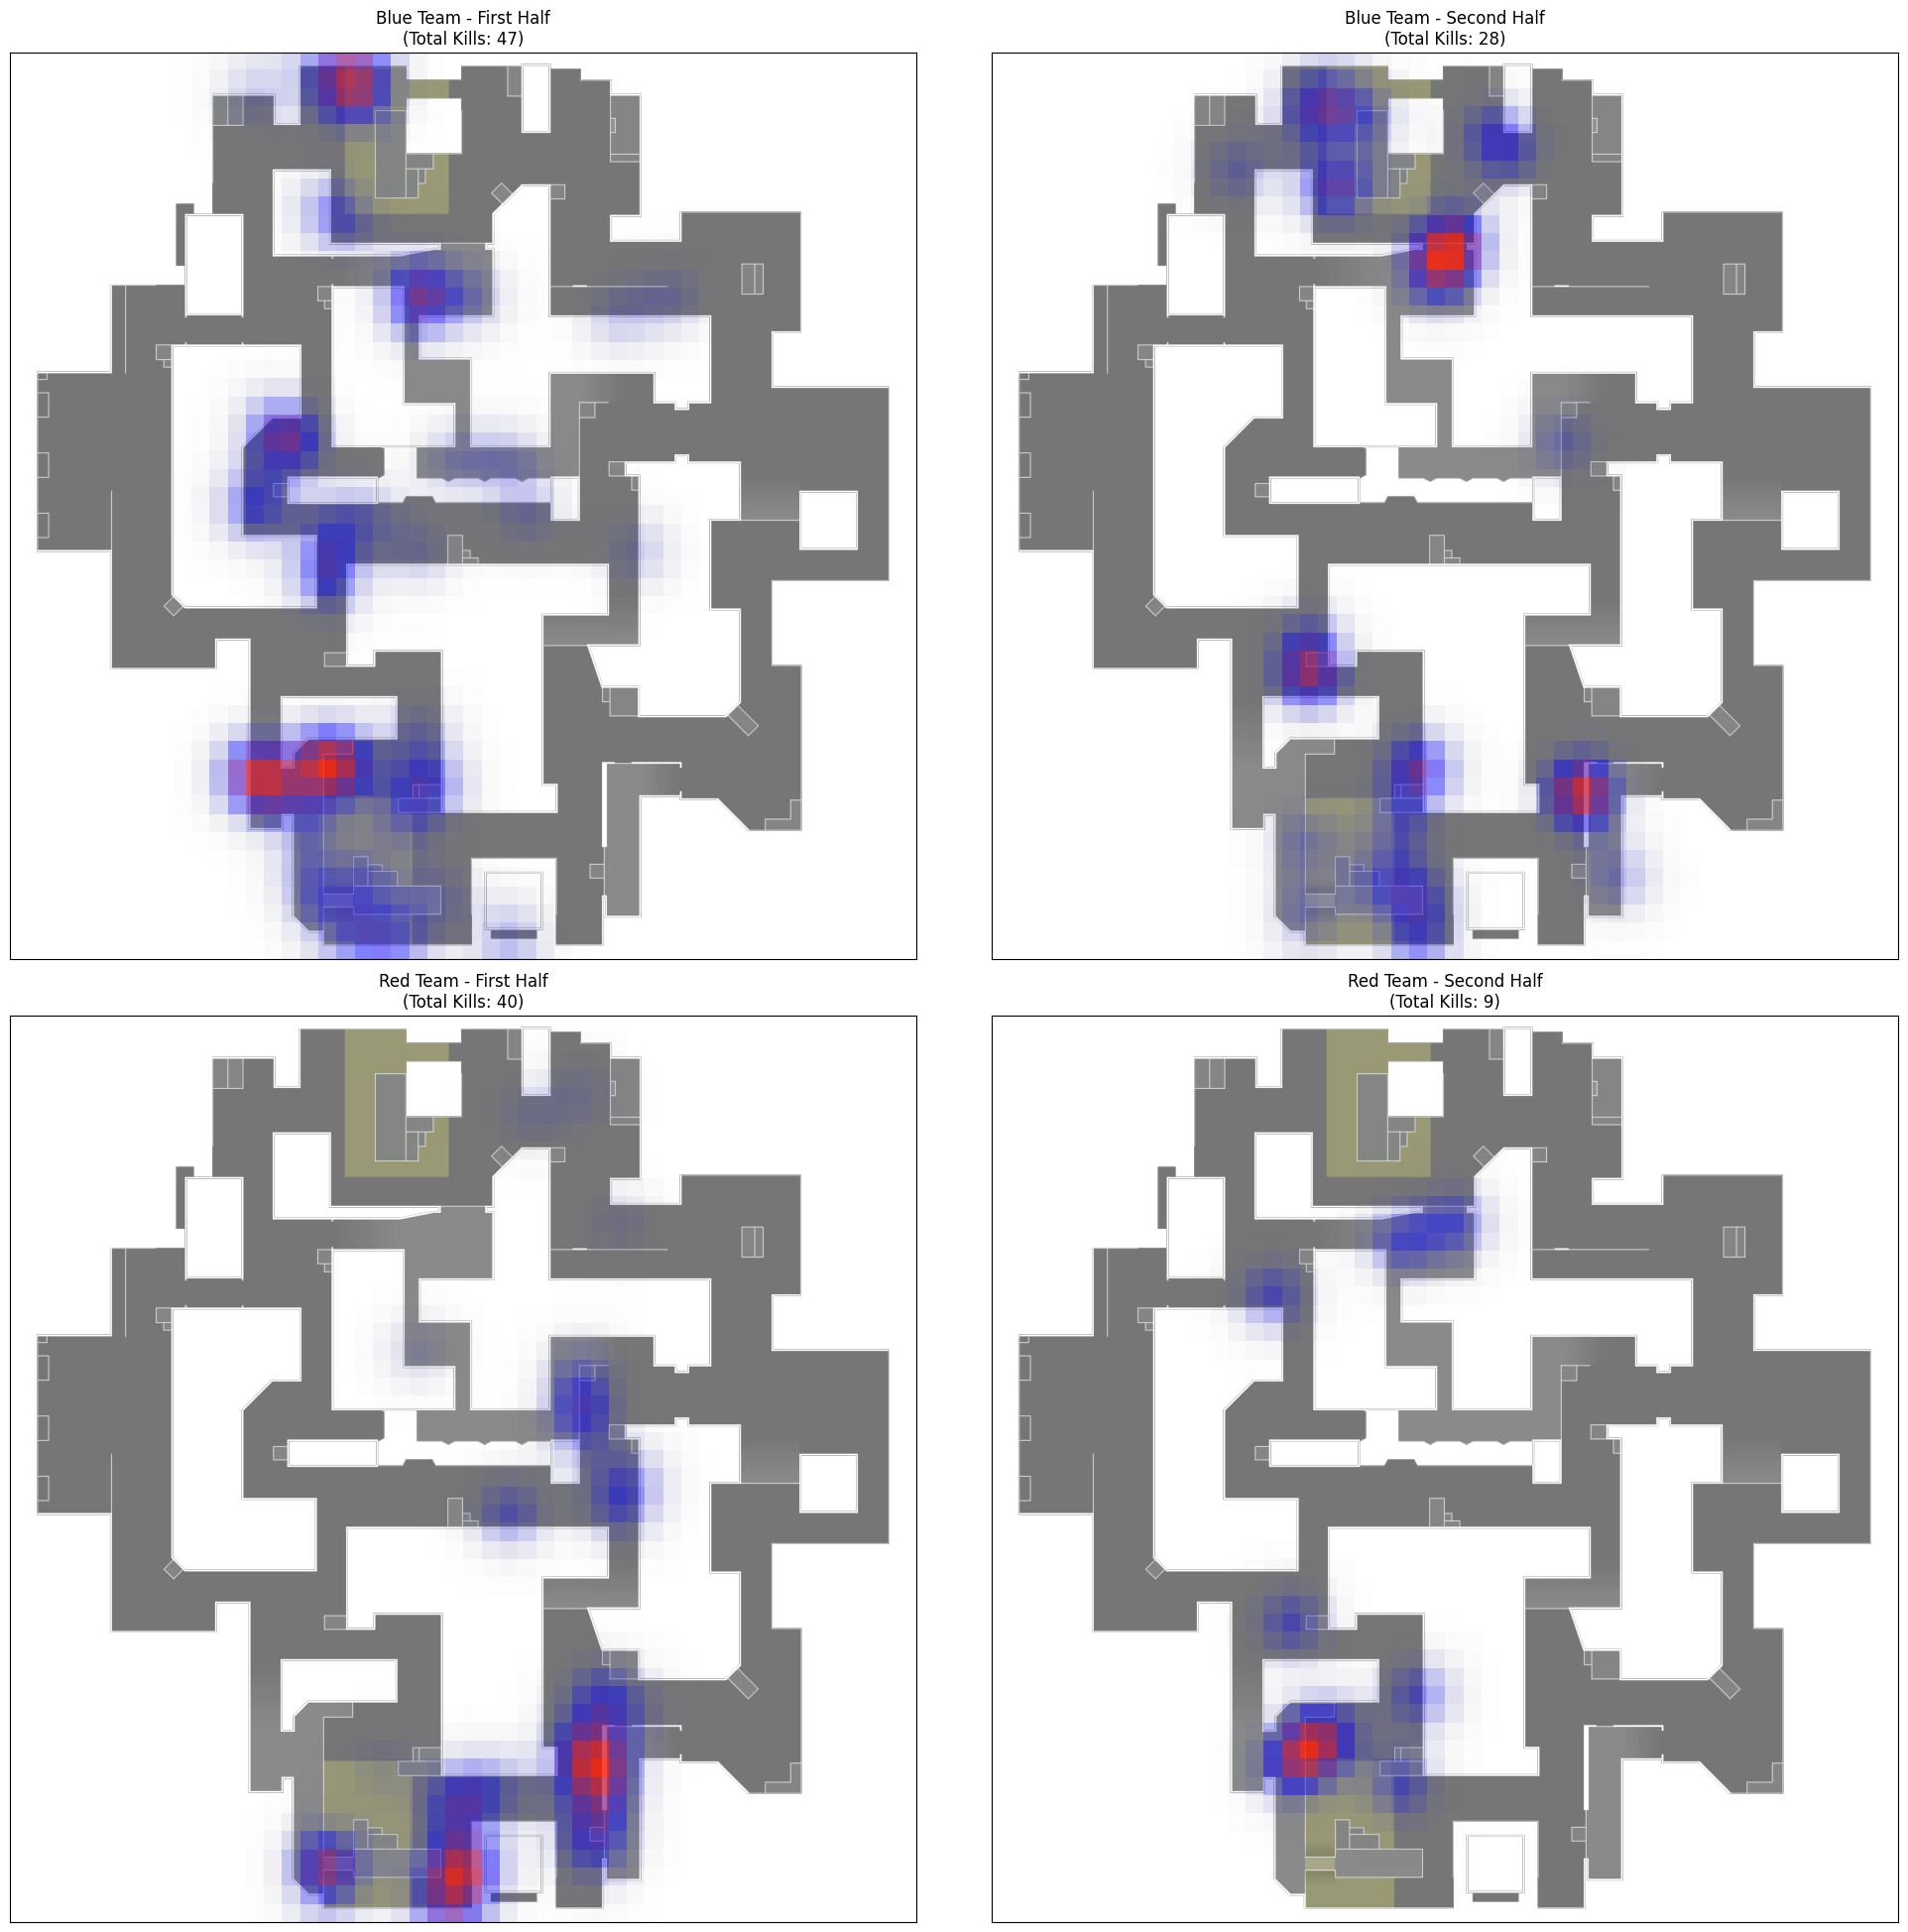

In [ ]:
# Create a custom colormap that goes from transparent gray to blue to orange-red
colors = [(0.5, 0.5, 0.5, 0.0),    # Transparent gray for low values
          (0.0, 0.0, 1.0, 0.5),    # Blue for medium-low values
          (1.0, 0.1, 0.0, 0.8)]    # Orange-red for high values
custom_cmap = LinearSegmentedColormap.from_list('blue_to_orange', colors)
 
# Create a mapping of player IDs to teams from player_stats_df
player_team_mapping = {}
for _, player_row in player_stats_df.iterrows():
    player_id = player_row['subject']
    team = player_row['teamId']
    player_team_mapping[player_id] = team
 
# Load the map image
minimap_url = match_info['minimap'].values[0]
map_image = Image.open(requests.get(minimap_url, stream=True).raw)
map_name = match_info['map'].values[0] if 'map' in match_info.columns else minimap_url.split('/')[-1].split('.')[0].capitalize()
 
# Create figure with four subplots (2x2: team x half)
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
 
# Labels for the halves
half_labels = ["First Half", "Second Half"]
 
# Process killer locations by team and half
blue_killer_x_first_half = []
blue_killer_y_first_half = []
red_killer_x_first_half = []
red_killer_y_first_half = []
blue_killer_x_second_half = []
blue_killer_y_second_half = []
red_killer_x_second_half = []
red_killer_y_second_half = []
 
for index in range(len(kill_data)):
    if 'killerLocation' not in kill_data.columns or kill_data['killerLocation'][index] is None:
        continue
 
    killer_id = kill_data['killer'][index]
    round_number = kill_data['round'][index] if 'round' in kill_data.columns else None
 
    if killer_id not in player_team_mapping or round_number is None:
        continue
 
    killer_team = player_team_mapping[killer_id]
    killer_location = kill_data['killerLocation'][index]
 
    try:
        x = killer_location['x']
        y = killer_location['y']
 
        # Determine which half the kill occurred in
        if 1 <= round_number <= 12:  # First half
            if killer_team in ['Blue', 'blue', 1]:
                blue_killer_x_first_half.append(x)
                blue_killer_y_first_half.append(y)
            elif killer_team in ['Red', 'red', 2]:
                red_killer_x_first_half.append(x)
                red_killer_y_first_half.append(y)
        elif 13 <= round_number <= 24:  # Second half
            if killer_team in ['Blue', 'blue', 1]:
                blue_killer_x_second_half.append(x)
                blue_killer_y_second_half.append(y)
            elif killer_team in ['Red', 'red', 2]:
                red_killer_x_second_half.append(x)
                red_killer_y_second_half.append(y)
    except (KeyError, TypeError):
        continue
 
# Function to create and plot heatmap
def plot_heatmap(ax, x_data, y_data, title, map_image):
    ax.imshow(map_image)
 
    if x_data and y_data:
        heatmap, xedges, yedges = np.histogram2d(
            x_data,
            y_data,
            bins=50,
            range=[[0, map_image.width], [0, map_image.height]]
        )
 
        heatmap = gaussian_filter(heatmap, sigma=1.5)
 
        extent = [0, map_image.width, map_image.height, 0]
        heatmap_plot = ax.imshow(
            heatmap.T,
            extent=extent,
            origin='upper',
            cmap=custom_cmap,
            vmin=0
        )
 
        total = len(x_data)
        ax.set_title(f'{title}\n(Total Kills: {total})')
    else:
        ax.set_title(f'{title}\nNo Kill locations found')
 
    ax.set_xticks([])
    ax.set_yticks([])
 
# Plot Blue Team First Half
plot_heatmap(axes[0, 0], blue_killer_x_first_half, blue_killer_y_first_half,
             f"Blue Team - {half_labels[0]}", map_image)
 
# Plot Blue Team Second Half
plot_heatmap(axes[0, 1], blue_killer_x_second_half, blue_killer_y_second_half,
             f"Blue Team - {half_labels[1]}", map_image)
 
# Plot Red Team First Half
plot_heatmap(axes[1, 0], red_killer_x_first_half, red_killer_y_first_half,
             f"Red Team - {half_labels[0]}", map_image)
 
# Plot Red Team Second Half
plot_heatmap(axes[1, 1], red_killer_x_second_half, red_killer_y_second_half,
             f"Red Team - {half_labels[1]}", map_image)
 
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

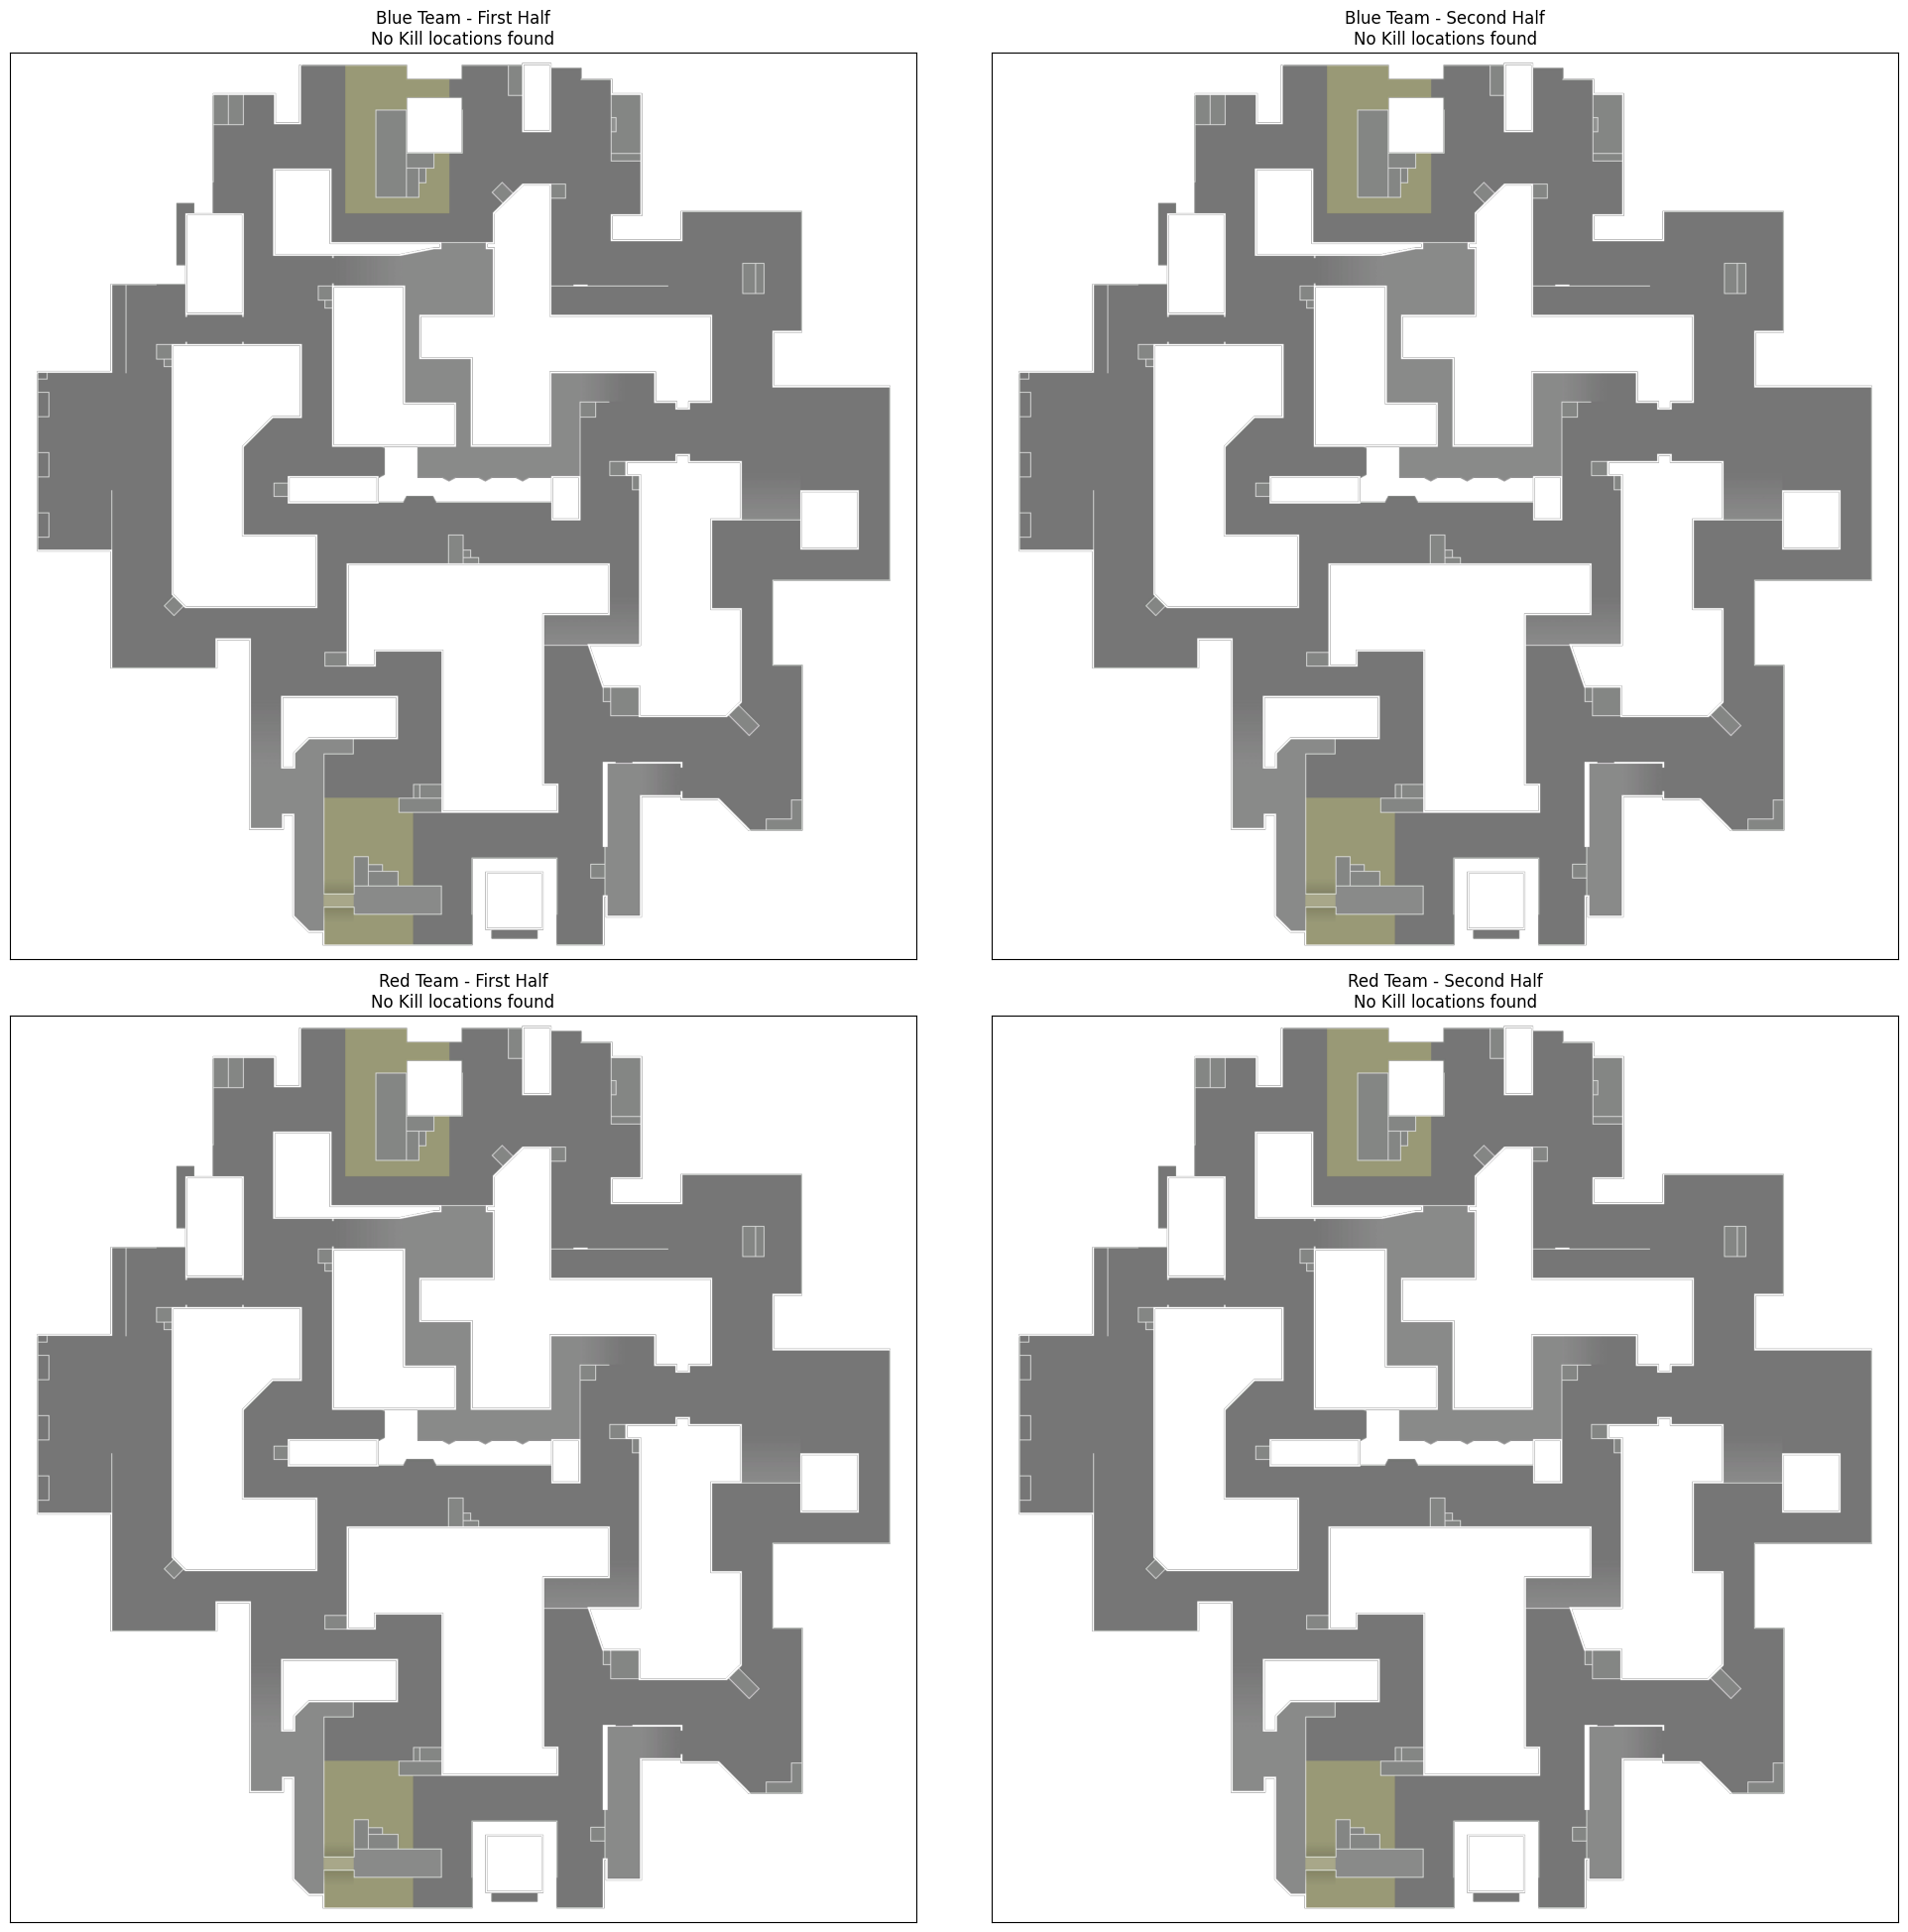

In [ ]:
# Create a custom colormap that goes from transparent gray to blue to orange-red
colors = [(0.5, 0.5, 0.5, 0.0),    # Transparent gray for low values
          (0.0, 0.0, 1.0, 0.5),    # Blue for medium-low values
          (1.0, 0.1, 0.0, 0.8)]    # Orange-red for high values
custom_cmap = LinearSegmentedColormap.from_list('blue_to_orange', colors)
 
# Create a mapping of player IDs to teams from player_stats_df
player_team_mapping = {}
for _, player_row in player_stats_df.iterrows():
    player_id = player_row['subject']
    team = player_row['teamId']
    player_team_mapping[player_id] = team
 
# Load the map image
minimap_url = match_info['minimap'].values[0]
map_image = Image.open(requests.get(minimap_url, stream=True).raw)
map_name = match_info['map'].values[0] if 'map' in match_info.columns else minimap_url.split('/')[-1].split('.')[0].capitalize()
 
# Create figure with four subplots (2x2: team x half)
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
 
# Labels for the halves
half_labels = ["First Half", "Second Half"]
 
# Process killer locations by team and half
blue_killer_x_first_half = []
blue_killer_y_first_half = []
red_killer_x_first_half = []
red_killer_y_first_half = []
blue_killer_x_second_half = []
blue_killer_y_second_half = []
red_killer_x_second_half = []
red_killer_y_second_half = []
 
for index in range(len(kill_data)):
    if 'killerLocation' not in kill_data.columns or kill_data['killerLocation'][index] is None:
        continue
 
    killer_id = kill_data['killer'][index]
    round_number = kill_data['round'][index] if 'round' in kill_data.columns else None
 
    if killer_id not in player_team_mapping or round_number is None:
        continue
 
    killer_team = player_team_mapping[killer_id]
    killer_location = kill_data['killerLocation'][index]
 
    try:
        x = killer_location['x']
        y = killer_location['y']
 
        # Determine which half the kill occurred in
        if 1 <= round_number <= 12:  # First half
            if killer_team in ['Blue', 'blue', 1]:
                blue_killer_x_first_half.append(x)
                blue_killer_y_first_half.append(y)
            elif killer_team in ['Red', 'red', 2]:
                red_killer_x_first_half.append(x)
                red_killer_y_first_half.append(y)
        elif 13 <= round_number <= 24:  # Second half
            if killer_team in ['Blue', 'blue', 1]:
                blue_killer_x_second_half.append(x)
                blue_killer_y_second_half.append(y)
            elif killer_team in ['Red', 'red', 2]:
                red_killer_x_second_half.append(x)
                red_killer_y_second_half.append(y)
    except (KeyError, TypeError):
        continue
 
# Function to create and plot heatmap
def plot_heatmap(ax, x_data, y_data, title, map_image):
    ax.imshow(map_image)
 
    if x_data and y_data:
        heatmap, xedges, yedges = np.histogram2d(
            x_data,
            y_data,
            bins=50,
            range=[[0, map_image.width], [0, map_image.height]]
        )
 
        heatmap = gaussian_filter(heatmap, sigma=1.5)
 
        extent = [0, map_image.width, map_image.height, 0]
        heatmap_plot = ax.imshow(
            heatmap.T,
            extent=extent,
            origin='upper',
            cmap=custom_cmap,
            vmin=0
        )
 
        total = len(x_data)
        ax.set_title(f'{title}\n(Total Kills: {total})')
    else:
        ax.set_title(f'{title}\nNo Kill locations found')
 
    ax.set_xticks([])
    ax.set_yticks([])
 
# Plot Blue Team First Half
plot_heatmap(axes[0, 0], blue_killer_x_first_half, blue_killer_y_first_half,
             f"Blue Team - {half_labels[0]}", map_image)
 
# Plot Blue Team Second Half
plot_heatmap(axes[0, 1], blue_killer_x_second_half, blue_killer_y_second_half,
             f"Blue Team - {half_labels[1]}", map_image)
 
# Plot Red Team First Half
plot_heatmap(axes[1, 0], red_killer_x_first_half, red_killer_y_first_half,
             f"Red Team - {half_labels[0]}", map_image)
 
# Plot Red Team Second Half
plot_heatmap(axes[1, 1], red_killer_x_second_half, red_killer_y_second_half,
             f"Red Team - {half_labels[1]}", map_image)
 
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

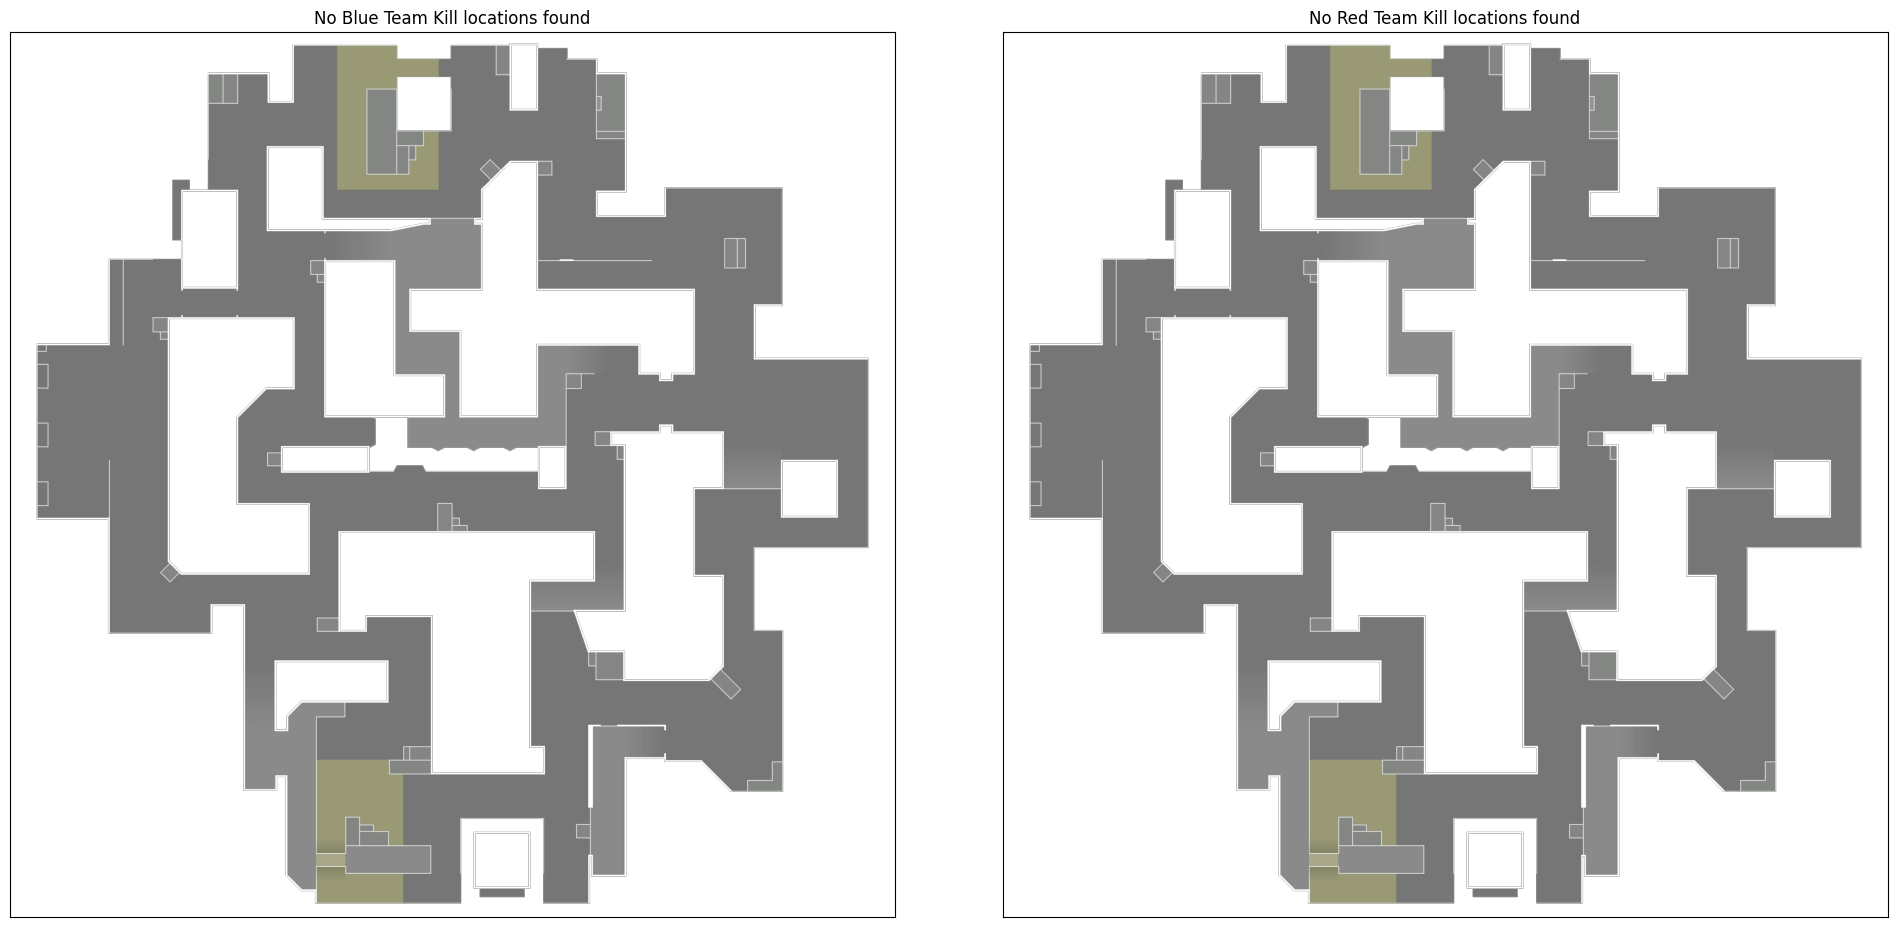

In [ ]:
# Create a custom colormap that goes from transparent gray to blue to orange-red
colors = [(0.5, 0.5, 0.5, 0.0),    # Transparent gray for low values
          (0.0, 0.0, 1.0, 0.5),    # Blue for medium-low values
          (1.0, 0.1, 0.0, 0.8)]    # Orange-red for high values
custom_cmap = LinearSegmentedColormap.from_list('blue_to_orange', colors)
 
# Create a mapping of player IDs to teams from player_stats_df
player_team_mapping = {}
for _, player_row in player_stats_df.iterrows():
    player_id = player_row['subject']
    team = player_row['teamId']
    player_team_mapping[player_id] = team
 
# Load the map image
minimap_url = match_info['minimap'].values[0]
map_image = Image.open(requests.get(minimap_url, stream=True).raw)
map_name = match_info['map'].values[0] if 'map' in match_info.columns else minimap_url.split('/')[-1].split('.')[0].capitalize()
 
# Create figure with two subplots (one for each team)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
 
# Process killer locations by team
blue_killer_x = []
blue_killer_y = []
red_killer_x = []
red_killer_y = []
 
for index in range(len(kill_data)):
    if 'killerLocation' not in kill_data.columns or kill_data['killerLocation'][index] is None:
        continue
       
    killer_id = kill_data['killer'][index]
   
    if killer_id not in player_team_mapping:
        continue
       
    killer_team = player_team_mapping[killer_id]
    killer_location = kill_data['killerLocation'][index]
   
    try:
        # Directly use killerLocation without normalization
        x = killer_location['x']
        y = killer_location['y']
       
        # Check for team ID - could be string or numeric depending on data
        if killer_team == 'Blue' or killer_team == 'blue' or killer_team == 1:
            blue_killer_x.append(x)
            blue_killer_y.append(y)
        elif killer_team == 'Red' or killer_team == 'red' or killer_team == 2:
            red_killer_x.append(x)
            red_killer_y.append(y)
    except (KeyError, TypeError):
        continue
 
# Display the map on both subplots
ax1.imshow(map_image)
ax2.imshow(map_image)
 
# Create Blue Team heatmap
if blue_killer_x and blue_killer_y:
    # Create a 2D histogram for blue team
    blue_heatmap, xedges, yedges = np.histogram2d(
        blue_killer_x,
        blue_killer_y,
        bins=50,
        range=[[0, map_image.width], [0, map_image.height]]
    )
   
    # Smooth the heatmap
    blue_heatmap = gaussian_filter(blue_heatmap, sigma=1.5)
   
    # Plot the blue team heatmap
    extent = [0, map_image.width, map_image.height, 0]
    blue_heatmap_plot = ax1.imshow(
        blue_heatmap.T,
        extent=extent,
        origin='upper',
        cmap=custom_cmap,
        vmin=0
    )
   
    blue_total = len(blue_killer_x)
    ax1.set_title(f'Blue Team Kill Locations\n(Total Kills: {blue_total})')
else:
    ax1.set_title('No Blue Team Kill locations found')
 
# Create Red Team heatmap
if red_killer_x and red_killer_y:
    # Create a 2D histogram for red team
    red_heatmap, xedges, yedges = np.histogram2d(
        red_killer_x,
        red_killer_y,
        bins=50,
        range=[[0, map_image.width], [0, map_image.height]]
    )
   
    # Smooth the heatmap
    red_heatmap = gaussian_filter(red_heatmap, sigma=1.5)
   
    # Plot the red team heatmap
    extent = [0, map_image.width, map_image.height, 0]
    red_heatmap_plot = ax2.imshow(
        red_heatmap.T,
        extent=extent,
        origin='upper',
        cmap=custom_cmap,
        vmin=0
    )
   
    red_total = len(red_killer_x)
    ax2.set_title(f'Red Team Kill Locations\n(Total Kills: {red_total})')
else:
    ax2.set_title('No Red Team Kill locations found')
 
# Remove axis ticks
ax1.set_xticks([])
ax1.set_yticks([])
ax2.set_xticks([])
ax2.set_yticks([])
 
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust for the overall title
plt.show()

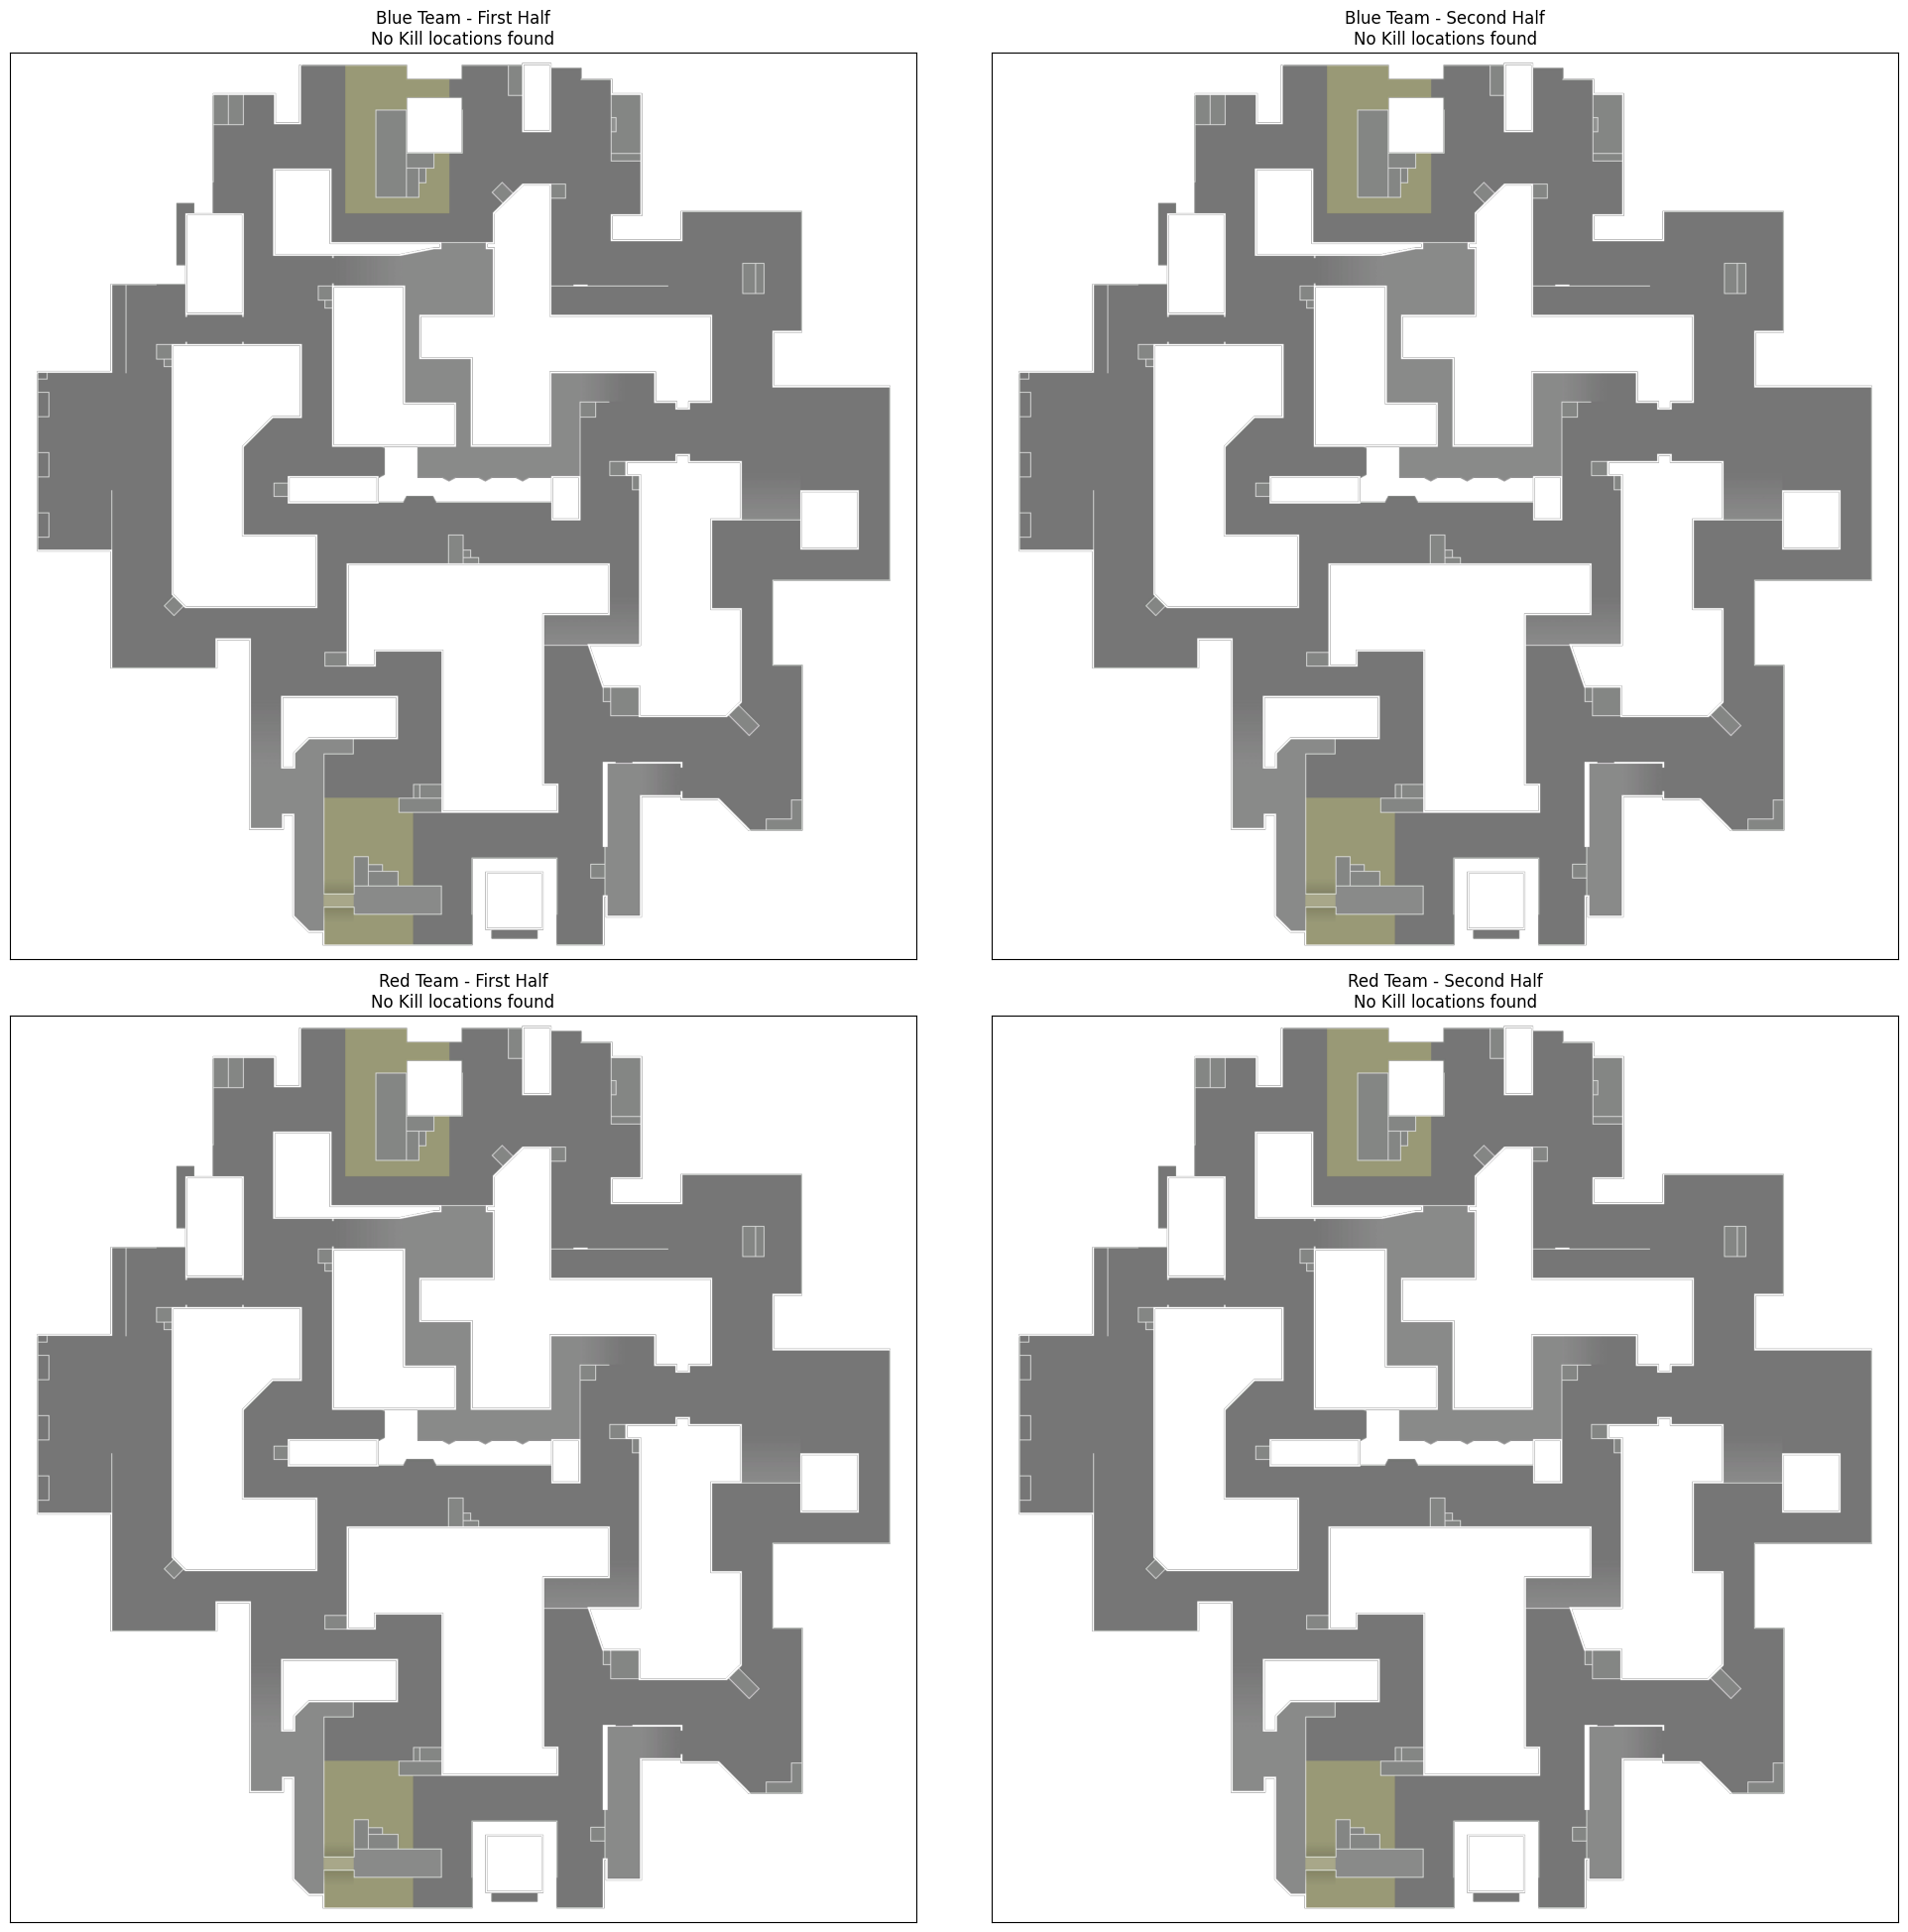

In [ ]:
# Create a custom colormap that goes from transparent gray to blue to orange-red
colors = [(0.5, 0.5, 0.5, 0.0),    # Transparent gray for low values
          (0.0, 0.0, 1.0, 0.5),    # Blue for medium-low values
          (1.0, 0.1, 0.0, 0.8)]    # Orange-red for high values
custom_cmap = LinearSegmentedColormap.from_list('blue_to_orange', colors)

# Create a mapping of player IDs to teams from player_stats_df
player_team_mapping = {}
for _, player_row in player_stats_df.iterrows():
    # Use 'subject' column for player ID
    player_id = player_row['subject']
    team = player_row['teamId']
    player_team_mapping[player_id] = team

# Load the map image
minimap_url = match_info['minimap'].values[0]
map_image = Image.open(requests.get(minimap_url, stream=True).raw)
map_name = match_info['map'].values[0] if 'map' in match_info.columns else minimap_url.split('/')[-1].split('.')[0].capitalize()

# Create figure with four subplots (2x2: team x half)
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# Labels for the halves
half_labels = ["First Half", "Second Half"]

# Process killer locations by team and half
blue_killer_x_first_half = []
blue_killer_y_first_half = []
red_killer_x_first_half = []
red_killer_y_first_half = []
blue_killer_x_second_half = []
blue_killer_y_second_half = []
red_killer_x_second_half = []
red_killer_y_second_half = []

for index in range(len(kill_data)):
    if 'killerLocation' not in kill_data.columns or kill_data['killerLocation'][index] is None:
        continue
        
    # Get killer ID and round number from events_df
    killer_id = kill_data['killer'][index]
    round_number = kill_data['round'][index] if 'round' in kill_data.columns else None
    
    # Skip if we can't find the killer's team or round information
    if killer_id not in player_team_mapping or round_number is None:
        continue
        
    killer_team = player_team_mapping[killer_id]
    killer_location = kill_data['killerLocation'][index]
    
    try:
        killer_point = normalise_coordinates(killer_location)
        
        # Determine which half the kill occurred in
        if 1 <= round_number <= 12:  # First half
            if killer_team == 'Blue' or killer_team == 'blue' or killer_team == 1:
                blue_killer_x_first_half.append(killer_point[0])
                blue_killer_y_first_half.append(killer_point[1])
            elif killer_team == 'Red' or killer_team == 'red' or killer_team == 2:
                red_killer_x_first_half.append(killer_point[0])
                red_killer_y_first_half.append(killer_point[1])
        elif 13 <= round_number <= 24:  # Second half
            if killer_team == 'Blue' or killer_team == 'blue' or killer_team == 1:
                blue_killer_x_second_half.append(killer_point[0])
                blue_killer_y_second_half.append(killer_point[1])
            elif killer_team == 'Red' or killer_team == 'red' or killer_team == 2:
                red_killer_x_second_half.append(killer_point[0])
                red_killer_y_second_half.append(killer_point[1])
    except (KeyError, TypeError):
        # Skip if the location data is malformed
        continue

# Function to create and plot heatmap
def plot_heatmap(ax, x_data, y_data, title, map_image):
    ax.imshow(map_image)
    
    if x_data and y_data:
        # Create a 2D histogram
        heatmap, xedges, yedges = np.histogram2d(
            x_data, 
            y_data, 
            bins=50, 
            range=[[0, map_image.width], [0, map_image.height]]
        )
        
        # Smooth the heatmap
        heatmap = gaussian_filter(heatmap, sigma=1.5)
        
        # Plot the heatmap
        extent = [0, map_image.width, map_image.height, 0]
        heatmap_plot = ax.imshow(
            heatmap.T, 
            extent=extent, 
            origin='upper',
            cmap=custom_cmap,
            vmin=0
        )
        
        total = len(x_data)
        ax.set_title(f'{title}\n(Total Kills: {total})')
    else:
        ax.set_title(f'{title}\nNo Kill locations found')
    
    # Remove axis ticks
    ax.set_xticks([])
    ax.set_yticks([])

# Plot Blue Team First Half
plot_heatmap(axes[0, 0], blue_killer_x_first_half, blue_killer_y_first_half, 
             f"Blue Team - {half_labels[0]}", map_image)

# Plot Blue Team Second Half
plot_heatmap(axes[0, 1], blue_killer_x_second_half, blue_killer_y_second_half, 
             f"Blue Team - {half_labels[1]}", map_image)

# Plot Red Team First Half
plot_heatmap(axes[1, 0], red_killer_x_first_half, red_killer_y_first_half, 
             f"Red Team - {half_labels[0]}", map_image)

# Plot Red Team Second Half
plot_heatmap(axes[1, 1], red_killer_x_second_half, red_killer_y_second_half, 
             f"Red Team - {half_labels[1]}", map_image)

plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust for the overall title
plt.show()

In [ ]:
# # Create a custom colormap that goes from transparent gray to blue to orange-red
# colors = [(0.5, 0.5, 0.5, 0.0),    # Transparent gray for low values
#         (0.0, 0.0, 1.0, 0.5),    # Blue for medium-low values
#         (1.0, 0.1, 0.0, 0.8)]    # Orange-red for high values
# custom_cmap = LinearSegmentedColormap.from_list('blue_to_orange', colors)

# # Create a mapping of player IDs to teams from player_stats_df
# player_team_mapping = {}
# for _, player_row in player_stats_df.iterrows():
#     player_id = player_row['subject']
#     team = player_row['teamId']
#     player_team_mapping[player_id] = team

# # Load the map image
# minimap_url = match_info['minimap'].values[0]
# map_image = Image.open(requests.get(minimap_url, stream=True).raw)
# map_name = match_info['map'].values[0] if 'map' in match_info.columns else minimap_url.split('/')[-1].split('.')[0].capitalize()

# # Labels for the halves
# half_labels = ["First Half", "Second Half"]

# st.subheader("Blue Team Event Heatmaps")

# # Create columns for the plots
# col3, col4 = st.columns(2)

# # Function to create and plot heatmap
# def plot_heatmap(x_data, y_data, title, map_image):
#     fig, ax = plt.subplots(figsize=(10, 10))
#     ax.imshow(map_image)
    
#     if x_data and y_data:
#         # Create a 2D histogram
#         heatmap, xedges, yedges = np.histogram2d(
#             x_data, 
#             y_data, 
#             bins=50, 
#             range=[[0, map_image.width], [0, map_image.height]]
#         )
        
#         # Smooth the heatmap
#         heatmap = gaussian_filter(heatmap, sigma=1.5)
        
#         # Plot the heatmap
#         extent = [0, map_image.width, map_image.height, 0]
#         ax.imshow(
#             heatmap.T, 
#             extent=extent, 
#             origin='upper',
#             cmap=custom_cmap,
#             vmin=0
#         )
        
#         total = len(x_data)
#         ax.set_title(f'{title}\n(Total: {total})', fontsize=14)
#     else:
#         ax.set_title(f'{title}\nNo locations found', fontsize=14)
    
#     # Remove axis ticks
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     plt.tight_layout()
#     return fig

# # Process killer locations for Blue team by half
# blue_killer_x_first_half = []
# blue_killer_y_first_half = []
# blue_killer_x_second_half = []
# blue_killer_y_second_half = []

# for index in range(len(match_data)):
#     if 'killerLocation' not in match_data.columns or match_data['killerLocation'][index] is None:
#         continue
        
#     # Get killer ID and round number from match_data
#     killer_id = match_data['killer'][index]
#     round_number = match_data['round'][index] if 'round' in match_data.columns else None
    
#     # Skip if we can't find the killer's team or round information
#     if killer_id not in player_team_mapping or round_number is None:
#         continue
        
#     killer_team = player_team_mapping[killer_id]
#     killer_location = match_data['killerLocation'][index]
    
#     try:
#         killer_point = normalise_coordinates(killer_location)
        
#         # Only process Blue team data
#         if killer_team == 'Blue' or killer_team == 'blue' or killer_team == 1:
#             # Determine which half the kill occurred in
#             if 1 <= round_number <= 12:  # First half
#                 blue_killer_x_first_half.append(killer_point[0])
#                 blue_killer_y_first_half.append(killer_point[1])
#             elif 13 <= round_number <= 24:  # Second half
#                 blue_killer_x_second_half.append(killer_point[0])
#                 blue_killer_y_second_half.append(killer_point[1])
#     except (KeyError, TypeError):
#         # Skip if the location data is malformed
#         continue

# # Process victim locations for Blue team by half
# blue_victim_x_first_half = []
# blue_victim_y_first_half = []
# blue_victim_x_second_half = []
# blue_victim_y_second_half = []

# for index in range(len(match_data)):
#     if 'victimLocation' not in match_data.columns or match_data['victimLocation'][index] is None:
#         continue
        
#     victim_id = match_data['victim'][index]
#     round_number = match_data['round'][index] if 'round' in match_data.columns else None
    
#     if victim_id not in player_team_mapping or round_number is None:
#         continue
        
#     victim_team = player_team_mapping[victim_id]
#     victim_location = match_data['victimLocation'][index]
    
#     try:
#         victim_point = normalise_coordinates(victim_location)
        
#         # Only process Blue team data
#         if victim_team == 'Blue' or victim_team == 'blue' or victim_team == 1:
#             if 1 <= round_number <= 12:  # First half
#                 blue_victim_x_first_half.append(victim_point[0])
#                 blue_victim_y_first_half.append(victim_point[1])
#             elif 13 <= round_number <= 24:  # Second half
#                 blue_victim_x_second_half.append(victim_point[0])
#                 blue_victim_y_second_half.append(victim_point[1])
#     except (KeyError, TypeError):
#         continue

# # Plot Blue Team First Half Kills
# with col3:
#     st.subheader(f"Blue Team Kills - {map_name}")
#     fig_kills_first_half = plot_heatmap(
#         blue_killer_x_first_half, 
#         blue_killer_y_first_half, 
#         f"Blue Team Kills - {half_labels[0]}", 
#         map_image
#     )
#     st.pyplot(fig_kills_first_half)

# # Plot Blue Team Second Half Kills
# with col4:
#     st.subheader("\u200B")  # Invisible header for alignment
#     fig_kills_second_half = plot_heatmap(
#         blue_killer_x_second_half, 
#         blue_killer_y_second_half, 
#         f"Blue Team Kills - {half_labels[1]}", 
#         map_image
#     )
#     st.pyplot(fig_kills_second_half)

# # Plot Blue Team First Half Deaths
# with col3:
#     st.subheader(f"Blue Team Deaths - {map_name}")
#     fig_deaths_first_half = plot_heatmap(
#         blue_victim_x_first_half, 
#         blue_victim_y_first_half, 
#         f"Blue Team Deaths - {half_labels[0]}", 
#         map_image
#     )
#     st.pyplot(fig_deaths_first_half)

# # Plot Blue Team Second Half Deaths
# with col4:
#     st.subheader("\u200B")  # Invisible header for alignment
#     fig_deaths_second_half = plot_heatmap(
#         blue_victim_x_second_half, 
#         blue_victim_y_second_half, 
#         f"Blue Team Deaths - {half_labels[1]}", 
#         map_image
#     )
#     st.pyplot(fig_deaths_second_half)